In [1]:
# %pip install torch_geometric
# %pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html

In [2]:
import DeviceDir

DIR, RESULTS_DIR = DeviceDir.get_directory()
device, NUM_PROCESSORS = DeviceDir.get_device()

In [3]:
DIR

'/scratch/gilbreth/das90/Dataset/'

In [4]:
import torch
from contextlib import contextmanager
import subprocess
import re

def get_gpu_memory_usage():
    result = subprocess.check_output(['nvidia-smi', '--query-gpu=memory.used', '--format=csv,nounits,noheader'])
    memory_usage = [int(x) for x in result.decode('utf-8').strip().split('\n')]
    return memory_usage

# Call this periodically during training to track memory usage
get_gpu_memory_usage()

# # At the start of your script
# torch.cuda.reset_peak_memory_stats()  # Reset memory statistics

# # ... your training loop ...

# # Get max memory used (in bytes)
# max_memory = torch.cuda.max_memory_allocated()
# print(f"Max GPU memory used: {max_memory / 1024**2:.2f} MB")

# # Optionally, get memory by device if using multiple GPUs
# for i in range(torch.cuda.device_count()):
#     max_memory = torch.cuda.max_memory_allocated(i)
#     print(f"Max GPU memory used on device {i}: {max_memory / 1024**2:.2f} MB")


# @contextmanager
# def track_memory_usage(description="", device=None):
#     if device is None:
#         device = torch.cuda.current_device()
#     torch.cuda.synchronize(device)
#     torch.cuda.reset_peak_memory_stats(device)
#     yield
#     torch.cuda.synchronize(device)
#     max_memory = torch.cuda.max_memory_allocated(device)
#     print(f"{description} Max GPU memory used: {max_memory / 1024**2:.2f} MB")
    


[4]

In [5]:
import os
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, Reddit
from torch_geometric.nn import GCNConv
from torch_geometric.loader import ClusterData, ClusterLoader
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import time
from torch_geometric.datasets import WikipediaNetwork
from sklearn.model_selection import train_test_split
from torch_geometric.typing import Adj, SparseTensor
from ogb.nodeproppred import Evaluator, PygNodePropPredDataset
from torch_geometric.utils import scatter
from torch_geometric.datasets import Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon,Coauthor,HeterophilousGraphDataset, CitationFull
from torch_geometric.utils import homophily
from torch_geometric.utils import negative_sampling
from torch_geometric.utils import add_random_edge

def fix_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_seeds()

In [6]:
all_dataset = [
    "Cornell",
    "Texas",
    "Wisconsin",
    "reed98",
    "amherst41",
    "penn94",
    "Roman-empire",
    "cornell5",
    "Squirrel",
    "johnshopkins55",
    "Actor",
    "Minesweeper",
    "Questions",
    "Chameleon",
    "Tolokers",
    "Amazon-ratings",
    "genius",
    "pokec",
    "arxiv-year",
    "snap-patents",
    "ogbn-proteins",
    "Cora",
    "DBLP",
    "Computers",
    "PubMed",
    "Cora_ML",
    "SmallCora",
    "CS",
    "Photo",
    "Physics",
    "CiteSeer",
    "wiki",
    "Reddit"
]

In [7]:
from ipynb.fs.full.SGSLoadDataset import LOAD_DATASET

DATASET_NAME = "johnshopkins55"
data, dataset  = LOAD_DATASET(DIR, DATASET_NAME)
num_classes = max(data.y).item()+1

if len(data.train_mask.shape)>1:
    index = 0
    data.train_mask = data.train_mask[:,index]
    data.val_mask = data.val_mask[:,index]
    if DATASET_NAME == 'wiki':
        None
    else:
        data.test_mask = data.test_mask[:,index]
    

data

johnshopkins55 N: 5180 E: 373172 F: 2406 C: 3 d: 72.04 lr: 0.60 i: False s: False u: True


Data(x=[5180, 2406], edge_index=[2, 373172], y=[5180], train_mask=[5180], val_mask=[5180], test_mask=[5180])

In [8]:
structure = False

In [9]:
He = homophily(data.edge_index, data.y, method='edge')
print("Edge Homophily: ", He)

Edge Homophily:  0.5001929402351379


In [10]:
class EdgeProbMLP(nn.Module):
    def __init__(self, in_channels, hidden_dim, dropout_prob=0.2):
        super(EdgeProbMLP, self).__init__()
        self.gcn1 = GCNConv(in_channels, hidden_dim) #sample 1 hop neighborhood
        self.dropout = nn.Dropout(dropout_prob)
#         self.gcn2 = GCNConv(hidden_dim, hidden_dim) #sample 2 hop neighborhood
        
#         self.fc_dim = nn.Linear(in_channels, hidden_dim)
#         self.dropout = nn.Dropout(dropout_prob)

        self.fc1 = nn.Linear(2 * hidden_dim, hidden_dim)
        
        # self.fc_residual = nn.Linear(2 * hidden_dim, hidden_dim)  # For residual connection
        # self.fc1 = nn.Linear(2 * in_channels, hidden_dim) #if straightforward link
        
        # self.dropout = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, node_features, edge_index):

        out = F.relu(self.gcn1(node_features, edge_index))
        out = self.dropout(out)
#         out = F.relu(self.gcn2(out, edge_index))
        
        x = out[edge_index[0]]
        y = out[edge_index[1]]
        
#         x = self.dropout(F.relu(self.fc_dim(node_features[edge_index[0]])))
#         y = self.dropout(F.relu(self.fc_dim(node_features[edge_index[1]])))

        edge_features = torch.cat([x*y,x-y], dim=1) #x*y|x-y
        x = F.relu(self.fc1(edge_features))
        # x = x + self.fc_residual(edge_features) #  # Add residual connection
        x = self.dropout(x)
        prob = torch.sigmoid(self.fc2(x))
        # prob.requires_grad_(True)
        return prob
    

In [11]:
from torch_geometric.nn import GCNConv, GATConv, GINConv, SAGEConv, ChebConv, GAT, GIN

In [12]:
class GINModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes, dropout_prob=0.2):
        super(GINModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim, dropout_prob)        
        self.dropout_prob = dropout_prob
        self.GIN = GIN(in_channels = in_channels,
                        hidden_channels = hidden_dim, 
                        num_layers = 2, out_channels = num_classes,
                        dropout = dropout_prob, 
                        act = 'relu')
                    
        
    def forward(self, data, edge_index, edge_weight=None):
        x = self.GIN(data.x, edge_index, edge_weight=edge_weight)
        return x

In [13]:
class GATModel(torch.nn.Module):        
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes, dropout_prob=0.2, heads=8):
        super(GATModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim, dropout_prob)        
        self.dropout_prob = dropout_prob
        
        self.GAT =  GAT(in_channels = in_channels,
                        hidden_channels = hidden_dim, 
                        num_layers = 2, out_channels = num_classes,
                        dropout = dropout_prob, 
                        act = 'relu')
        
    def forward(self, data, edge_index, edge_weight=None):
        x = self.GAT(data.x, edge_index, edge_weight=edge_weight)        
        return x

In [14]:
class ChebModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes, dropout_prob=0.3):
        super(ChebModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim, dropout_prob)
        self.dropout_prob = dropout_prob
        
        self.gcn1 = ChebConv(in_channels, hidden_dim, K=1, normalization='sym')
        self.dropout = nn.Dropout(dropout_prob)
        self.gcn2 = ChebConv(hidden_dim, num_classes, K=1, normalization='sym')

    def forward(self, data, edge_index, edge_weight=None):
        x = F.relu(self.gcn1(data.x, edge_index, edge_weight))
        x = self.dropout(x)
        out = self.gcn2(x, edge_index, edge_weight)
        return out

In [15]:
class GNNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes, dropout_prob=0.3):
        super(GNNModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim, dropout_prob)
        # self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim)
        self.gcn1 = GCNConv(in_channels, hidden_dim)
        self.dropout = nn.Dropout(dropout_prob)
        self.gcn2 = GCNConv(hidden_dim, num_classes)

    def forward(self, data, edge_index, edge_weight=None):
        x = F.relu(self.gcn1(data.x, edge_index, edge_weight))
        x = self.dropout(x)
        out = self.gcn2(x, edge_index, edge_weight)
        return out

In [16]:
# model = GATModel(in_channels=data.x.shape[1], hidden_dim=16, out_channels=0, num_classes=dataset.num_classes, dropout_prob=0.3)

# for name, param in model.named_parameters():
#     print(name)
#     if 'GAT' in name or 'gcn' in name:
#         print("->>",name)

In [17]:
import os
data

Data(x=[5180, 2406], edge_index=[2, 373172], y=[5180], train_mask=[5180], val_mask=[5180], test_mask=[5180])

In [18]:
plt.rcParams['text.usetex'] = True

def plot_probs(edge_probs,sampling_probs):
    ep = edge_probs.detach().cpu().numpy()
    sp = sampling_probs.detach().cpu().numpy()
    
    plt.figure(figsize=(20, 6))    
    plt.subplot(2, 1, 1)

    #plt.plot(ep)
    plt.scatter(range(len(ep)), ep, s=2)
    plt.title('Curve of Edge Probs')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.grid(True)

    plt.subplot(2, 1, 2)
    #plt.plot(sp)
    plt.scatter(range(len(sp)), sp, s=2)
    plt.title('Curve of Samples Probs')
    plt.xlabel('Index')
    plt.ylabel('Probability')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
    
def plot_hist(edge_probs,sampling_probs, ep_select, sp_select, isprior=False):
    
    sp = sampling_probs.detach().cpu().numpy()
    if edge_probs is not None:
        ep = edge_probs.detach().cpu().numpy()
    
    if ep_select is not None and sp_select is not None:        
        ep_select = ep_select.detach().cpu().numpy()
        sp_select = sp_select.detach().cpu().numpy()
    
    fig = plt.figure(figsize=(20, 10))    
    ax = fig.add_subplot(111)
    
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    fontsize = 32
    
        
#     if edge_probs is not None:
#         plt.subplot(2, 1, 1)
#         #plt.plot(ep)
#         plt.hist(ep, bins= 30, edgecolor='black')
#         plt.title('Histogram of edge weight ($w$)')
#         plt.xlabel('Edge weight ($w$)')
#         plt.ylabel('Count')
#         plt.grid(True)
    
#     if edge_probs is not None:
#         plt.subplot(2, 1, 2)
#     else:
#         plt.subplot(2, 1, 1)
    #plt.plot(sp)
    plt.hist(sp, bins= 30, edgecolor='black')
    
    plt.xticks(fontname="Times New Roman", fontsize=fontsize)
    plt.yticks(fontname="Times New Roman", fontsize=fontsize)
    
#     if isprior:
#         plt.title(r'Histogram of prior probability distribution ($p_\mathrm{prior}$)', fontname="Times New Roman", fontsize=fontsize)
#         plt.xlabel(r'Probability ($p_\mathrm{prior}$)', fontname="Times New Roman", fontsize=fontsize)
#     else:
#         plt.title(r'Histogram of learned probability distribution ($\tilde{p}$)', fontname="Times New Roman", fontsize=fontsize)
#         plt.xlabel(r'Probability $\tilde{p}$', fontname="Times New Roman", fontsize=fontsize)
    
    # augmented
    if isprior:
        plt.title(r'Histogram of prior probability distribution ($p_\mathrm{prior}$)', fontname="Times New Roman", fontsize=fontsize)
        plt.xlabel(r'Probability ($p_\mathrm{prior}$)', fontname="Times New Roman", fontsize=fontsize)
    else:
        plt.title(r'Histogram of augmented learned probability distribution ($\tilde{p}_a$)', fontname="Times New Roman", fontsize=fontsize)
        plt.xlabel(r'Probability $\tilde{p}_a$', fontname="Times New Roman", fontsize=fontsize)
    
    
    
    plt.ylabel('Count', fontname="Times New Roman", fontsize=fontsize)
    
    plt.grid(False)

#     plt.subplot(4, 1, 3)
#     #plt.plot(sp)
#     plt.hist(ep_select, bins= 30, edgecolor='black')
#     plt.title('histogram of selected Edge Probs')
#     plt.xlabel('Index')
#     plt.ylabel('Probability')
#     plt.grid(True)
    
#     plt.subplot(4, 1, 4)
#     #plt.plot(sp)
#     plt.hist(sp_select, bins= 30, edgecolor='black')
#     plt.title('histogram of selected sampled Probs')
#     plt.xlabel('Index')
#     plt.ylabel('Probability')
#     plt.grid(True)

    
    plt.tight_layout()
    
    output_dir = "DistFigures/"
    os.makedirs(output_dir, exist_ok=True)
        
    if isprior == False:        
        filename = os.path.join(output_dir, "SGS-learnedp_a.pdf")
    else:
        filename = os.path.join(output_dir, "SGS-prior.pdf")
    
    fig.savefig(filename, format="pdf", bbox_inches="tight")
    
    plt.show()

In [19]:
from torch_geometric.utils import to_scipy_sparse_matrix
import scipy.sparse as sp

In [20]:
# Gumbel-Softmax trick for edge sampling
def gumbel_softmax_sampling(batch, edge_probs, edge_index, q=500, temperature=1.0, log=False, istest=False, epoch=-1):
        
    if istest:
        # samples = torch.exp(edge_probs)/torch.exp(edge_probs).sum()
        samples = edge_probs/edge_probs.sum()
        #samples = 0.7 * samples + 0.3*batch.prob #temporary
#         top_k_values, sampled_edges = torch.topk(samples, q, dim=-1, largest=True, sorted=True)
        #sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing
        
#         samples = F.softmax(edge_probs/temperature, dim=-1)
        sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing
#         top_k_values, sampled_edges = torch.topk(edge_probs, q, dim=-1, largest=True, sorted=True)
        # edge_gradients = edge_probs.grad
        # sampled_edges = torch.topk(edge_gradients.abs(),k=q)
    else:
        # warmup_epochs = 20  # Number of epochs for the warm-up phase
        # if epoch< warmup_epochs:
            # samples = F.softmax(batch.prob, dim=-1)
            # sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing               
        # else:
#         samples = torch.exp(edge_probs)/torch.exp(edge_probs).sum()
        # edge_probs += torch.ones_like(edge_probs)/len(edge_probs)
        samples =  edge_probs/edge_probs.sum()
        
#         print(edge_probs)
#         print(torch.sum(edge_probs))
#         print(torch.sum(samples))
        
#         samples = F.softmax(edge_probs/temperature, dim=-1)
#         samples = 0.1*samples + 0.9*torch.rand_like(samples)
#         samples = 0.7 * samples + 0.3*batch.prob    
        sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing
#         gumbels = -torch.empty_like(edge_probs).exponential_().log()
#         gumbels = (gumbels - gumbels.min()) / (gumbels.max() - gumbels.min())
        
#         #noise = 1.0 + (epoch/100)*9.0
#         noise = 1.0
        
#         gumbels = gumbels/noise
        
    
# #         gumbels = 0

#         logits = (edge_probs + gumbels) / temperature    
#         samples = F.softmax(logits, dim=-1)

#         top_k_values, sampled_edges = torch.topk(samples, q, dim=-1, largest=True, sorted=True) # 50       
        
    
        #print(f'{torch.mean(samples).item():.4f}, {torch.var(samples).item():.4f}, {torch.std(samples).item():.4f}')    
        #print("EP: ",torch.mean(edge_probs).item(), torch.var(edge_probs).item())
        #print("SP: ",torch.mean(samples).item(), torch.var(samples).item())
    
#     print("Test" if istest == True else "Train")
    
#     if epoch%10 == 0:    
#         print("Epoch :", epoch, end="-------->")        
#     #     print(edge_probs)
#     #     print(samples)   
#     #         #plot_probs(edge_probs, samples)
#         plot_hist(edge_probs, samples, edge_probs[sampled_edges],samples[sampled_edges])

# #         adj = to_scipy_sparse_matrix(data.edge_index[:,sampled_edges], num_nodes=data.num_nodes)
# #         num_components, component = sp.csgraph.connected_components(adj, connection='weak')
# #         print("Components: ", num_components)
    
# #     sampled_edges = torch.multinomial(samples, q, replacement=False)
# #     top_k_values, sampled_edges = torch.topk(edge_probs, q, dim=-1, largest=True, sorted=True)    

    
    one_hot = torch.zeros_like(samples)
    one_hot.scatter_(0, sampled_edges, 1.0)     
    
    indexs = (one_hot - samples).detach() + samples
    
    edge_probs = edge_probs*indexs
    indexs = indexs.bool()
    
    
#     if log:        
#         print("edge_probs: ",edge_probs)
# #         print("gumbels: ", gumbels)
# #         print("logits: ",logits)
#         print("samples: ",samples)
#         print("sampled_edges: ",sampled_edges)
#         print("One hot: ", one_hot)
#         print("Indexs: ",indexs)
#         print("edge_probs[indexs]:", edge_probs[indexs])

    
#     return indexs, edge_probs[indexs]
    
    return indexs, edge_probs[indexs]+0.01
    #return indexs, torch.clamp(edge_probs[indexs]+10, max=1.0)


# Random edge sampling
def random_edge_sampling(edge_index, q):
    num_edges = edge_index.shape[1]
    sampled_indices = torch.randperm(num_edges)[:q]
    sampled_edge_index = edge_index[:, sampled_indices]
    return sampled_edge_index

# F1 score calculation helper
def calculate_f1(logits, labels, mask):
    preds = logits[mask].argmax(dim=1)
    f1 = f1_score(labels[mask].cpu(), preds.cpu(), average='micro')
    return f1

def compute_node_similarity(node_embeddings):
    """
    Compute pairwise node similarity using cosine similarity.
    Args:
        node_embeddings (torch.Tensor): Node embeddings, shape [num_nodes, embedding_dim].
    Returns:
        torch.Tensor: Pairwise similarity matrix, shape [num_nodes, num_nodes].
    """
    similarity_matrix = F.cosine_similarity(
        node_embeddings.unsqueeze(1), node_embeddings.unsqueeze(0), dim=-1
    )
    return similarity_matrix

def consistency_loss(edge_probs, edge_indices, node_embeddings):
    """
    Consistency loss to align edge probabilities with global node similarity.
    Args:
        edge_probs (torch.Tensor): Predicted edge probabilities, shape [num_edges].
        edge_indices (torch.Tensor): Indices of edges, shape [2, num_edges].
        node_embeddings (torch.Tensor): Node embeddings, shape [num_nodes, embedding_dim].
    Returns:
        torch.Tensor: Consistency loss.
    """
    # print(edge_indices.shape)
    # Compute similarity matrix
    # similarity_matrix = compute_node_similarity(node_embeddings)
    
    # Extract similarities for given edges
    src, dst = edge_indices  # Split edge indices into source and destination
    # edge_similarities = similarity_matrix[src, dst]
    src_embeddings = node_embeddings[src]
    dst_embeddings = node_embeddings[dst]
    # Compute cosine similarity for edge pairs
    edge_similarities = F.cosine_similarity(src_embeddings, dst_embeddings, dim=-1)
    
    # Consistency loss as MSE between edge probabilities and node similarities
    loss = F.mse_loss(edge_probs[src], edge_similarities)
    return loss


# Training function with alternating updates
def train(epoch, max_epoch, model, optimizer_gnn, optimizer_edge_prob, optimizer, criterion, cluster_loader, device, q=500, mode='learned', alternate_frequency=1):
    model.train()
    total_loss = 0
    iteration = 0

    for batch in cluster_loader:
        if not batch.train_mask.any():
            continue

        batch = batch.to(device)
        
#         if alternate_frequency == 0:
#             update_gnn = True
#             update_edge_prob = True
#         else:            
#             # Decide if we are updating GNN or edge probability model
#             update_gnn = iteration % alternate_frequency == 0
#             update_edge_prob = not update_gnn
        # Zero gradients selectively        
#         if update_gnn:
#             optimizer_gnn.zero_grad()
#         if update_edge_prob:
#             optimizer_edge_prob.zero_grad()
        
        optimizer_edge_prob.zero_grad()
        optimizer_gnn.zero_grad()
        
        #optimizer.zero_grad()

        # Select edges based on mode
        if mode == 'learned':
            if batch.edge_index.shape[1] > q:
                edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()   
                # edge_probs.retain_grad()
                # edge_probs.requires_grad = True                 
                # temperature = 2.0 - (epoch * (2 - 0.5) / max_epoch)
                # temperature = 1.0
                temperature = max(0.5, 0.7 - epoch*0.01) # Annealing (improves very little)
                #print(temperature)                
                sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(batch, edge_probs, batch.edge_index, q=q, temperature=temperature, log=(epoch==max_epoch-1),epoch=epoch)
                sampled_edge_index = batch.edge_index[:, sampled_edge_indices]      
                learned_out = model(batch, sampled_edge_index, sampled_edge_weight) 
                #out = model(batch, sampled_edge_index, None)     
                loss = criterion(learned_out[batch.train_mask], batch.y[batch.train_mask])
                loss.backward()
                optimizer_edge_prob.step()
                optimizer_gnn.step()

#                 # random_edge_index = random_edge_sampling(batch.edge_index,q)
#                 # random_out = model(batch,random_edge_index)

#                 ###- firx prior---
#                 #with torch.no_grad():
#                 samples = F.softmax(batch.prob, dim=-1)
#                 edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
#                 sampled_edge_index = batch.edge_index[:,edge_sample]                
#                 random_out = model(batch,sampled_edge_index)

#                 # Calculate F1 scores for learned and random sampling
#                 learned_f1 = calculate_f1(learned_out, batch.y, batch.train_mask)
#                 random_f1 = calculate_f1(random_out, batch.y, batch.train_mask)
#                 # Compute loss for learned edges            

#                 if learned_f1 > random_f1:

#                     loss = criterion(learned_out[batch.train_mask], batch.y[batch.train_mask])


# #                     # Compute node classification loss
# #                     # loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
# #                     # loss = loss + 0.001 * torch.sum(torch.square(edge_probs))

#                     #######---regularizer 1
#                     edge_labels = torch.full((batch.edge_index.size(1),), -1, dtype=torch.long, device=device)
#                     train_indices = torch.nonzero(batch.train_mask).squeeze()
#                     train_edge_mask = torch.isin(batch.edge_index[0], train_indices) & torch.isin(batch.edge_index[1], train_indices)

#                     # Assign labels based on the class of the endpoints
#                     same_class_mask = batch.y[batch.edge_index[0]] == batch.y[batch.edge_index[1]]
#                     edge_labels[train_edge_mask & same_class_mask] = 1
#                     edge_labels[train_edge_mask & ~same_class_mask] = 0

#                     # Filter out the edges with labels -1
#                     valid_edge_mask = edge_labels != -1
#                     valid_edge_probs = edge_probs[valid_edge_mask]
#                     valid_edge_labels = edge_labels[valid_edge_mask]

#                     #print(torch.sum(valid_edge_labels))
#                     if torch.sum(valid_edge_labels).item() > 1:            
#                         loss2 = F.binary_cross_entropy(valid_edge_probs, valid_edge_labels.float().to(device))
#                     else:
#                         loss2 = 0

#                     loss = loss+loss2


#                     global_consistency_loss = consistency_loss(edge_probs,sampled_edge_index, learned_out)
#                     loss = loss + 0.5 *global_consistency_loss


    #     #             ########---regularizer 2

    #                 train_indices = torch.nonzero(batch.train_mask).squeeze()            
    #                 num_nodes = train_indices.size(0)
    #                 #num_edges = min(num_nodes*num_nodes,q)  # Adjust the number of edges as needed
    #                 num_edges = num_nodes*num_nodes

    #                 # Generate random edges
    #                 src = torch.randint(0, num_nodes, (num_edges,))
    #                 dst = torch.randint(0, num_nodes, (num_edges,))

    #                 # Map to actual node indices
    #                 src_nodes = train_indices[src]
    #                 dst_nodes = train_indices[dst]

    #                 # Create edge_index tensor
    #                 reg_edge_index = torch.stack([src_nodes, dst_nodes], dim=0).to(device)
    #                 reg_edge_label = (batch.y[src_nodes] == batch.y[dst_nodes]).float().to(device)            
    #                 reg_edge_probs = model.edge_prob_mlp(batch.x, reg_edge_index).squeeze()

    #                 loss4 = F.binary_cross_entropy(reg_edge_probs, reg_edge_label)

    #                 #print(reg_edge_index)
    #                 #print(reg_edge_label)

    #                 loss = loss+loss4




#                     loss.backward()
#                     optimizer_edge_prob.step()
#                     optimizer_gnn.step()
#                     #optimizer.step()                
#                     #print("learned..")
#                 else:
#                     loss = criterion(random_out[batch.train_mask], batch.y[batch.train_mask])
#                     loss.backward()
#                     optimizer_gnn.step()
#                     #optimizer.zero_grad()
#                     #print("Random..")
                    
            else:
                out = model(batch, batch.edge_index)
                loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
                loss.backward()
                optimizer_gnn.step()
                
        # loss.backward()
        # importance_score = edge_probs.grad.abs().detach().cpu().numpy()

#         # Update parameters selectively
#         if update_gnn:
#             optimizer_gnn.step()
#         if update_edge_prob:
#             optimizer_edge_prob.step()

        # optimizer.step()
    
    
        elif mode == 'random':
            if batch.edge_index.shape[1] > q:
                sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                
#                 adj = to_scipy_sparse_matrix(sampled_edge_index, num_nodes=data.num_nodes)
#                 num_components, component = sp.csgraph.connected_components(adj, connection='weak')
#                 print("Components in random: ", num_components)
                
                out = model(batch, sampled_edge_index)
            else:
                out = model(batch, batch.edge_index)
            
            loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
            loss.backward()
            optimizer.step()
                
        elif mode == 'edge':
            if batch.edge_index.shape[1] > q:
                
                samples = F.softmax(batch.prob, dim=-1)
                # samples = batch.prob/batch.prob.sum()
                edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
                sampled_edge_index = batch.edge_index[:,edge_sample]                
                #print(sampled_edge_index.shape)
                
#                 adj = to_scipy_sparse_matrix(sampled_edge_index, num_nodes=data.num_nodes)
#                 num_components, component = sp.csgraph.connected_components(adj, connection='weak')
#                 print("Components in edge: ", num_components)
                
                out = model(batch, sampled_edge_index)
            else:
                out = model(batch, batch.edge_index)
            
            loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
            loss.backward()
            optimizer.step()
            
        elif mode == 'full':
            out = model(batch, batch.edge_index)
            loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
            loss.backward()
            optimizer.step()
            
        else:
            raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")
        

        total_loss += loss.item()
        iteration += 1

    # return total_loss / len(cluster_loader), importance_score
    return total_loss / len(cluster_loader), None

# Evaluation function remains unchanged
def evaluate(model, cluster_loader, device, q=500, mode=None):
    model.eval()
    total_train_f1, total_val_f1, total_test_f1 = 0, 0, 0
    num_train_examples, num_val_examples, num_test_examples = 0, 0, 0

    with torch.no_grad():
        for batch in cluster_loader:
            batch = batch.to(device)
            if mode == 'learned':
                if batch.edge_index.shape[1] > q:
                    edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()                    
                    sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(batch, edge_probs, batch.edge_index, q=q, istest=True)
                    sampled_edge_index = batch.edge_index[:, sampled_edge_indices]
                    out = model(batch, sampled_edge_index, sampled_edge_weight)                                        
                    #out = model(batch, sampled_edge_index, None)                                        
                else:
                    out = model(batch, batch.edge_index)
            elif mode == 'random':
                if batch.edge_index.shape[1] > q:
                    sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                    out = model(batch, sampled_edge_index)
                else:
                    out = model(batch, batch.edge_index)
                    
            elif mode == 'edge':
                if batch.edge_index.shape[1] > q:
                    samples = F.softmax(batch.prob, dim=-1)
                    edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
                    sampled_edge_index = batch.edge_index[:,edge_sample]                
                    #print(sampled_edge_index.shape)
                    out = model(batch, sampled_edge_index)                
                else:
                    out = model(batch, batch.edge_index)
                    
            
            elif mode == 'full':
                out = model(batch, batch.edge_index)
            else:
                raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")

            # Calculate F1 scores for train, val, and test sets if masks are present
            if batch.train_mask.any():
                train_f1 = calculate_f1(out, batch.y, batch.train_mask)
                total_train_f1 += train_f1 * batch.train_mask.sum().item()
                num_train_examples += batch.train_mask.sum().item()

            if batch.val_mask.any():
                val_f1 = calculate_f1(out, batch.y, batch.val_mask)
                total_val_f1 += val_f1 * batch.val_mask.sum().item()
                num_val_examples += batch.val_mask.sum().item()

            if batch.test_mask.any():
                test_f1 = calculate_f1(out, batch.y, batch.test_mask)
                total_test_f1 += test_f1 * batch.test_mask.sum().item()
                num_test_examples += batch.test_mask.sum().item()

    avg_train_f1 = total_train_f1 / num_train_examples if num_train_examples > 0 else 0
    avg_val_f1 = total_val_f1 / num_val_examples if num_val_examples > 0 else 0
    avg_test_f1 = total_test_f1 / num_test_examples if num_test_examples > 0 else 0

    return avg_train_f1, avg_val_f1, avg_test_f1

# Evaluation function remains unchanged
def ensemble_evaluate(model, cluster_loader, device, q=500, mode=None):
    model.eval()
    total_train_f1, total_val_f1, total_test_f1 = 0, 0, 0
    num_train_examples, num_val_examples, num_test_examples = 0, 0, 0

    with torch.no_grad():
        for batch in cluster_loader:
            batch = batch.to(device)
            
            outs = []
            
            for i in range(11):                    
                if mode == 'learned':
                    if batch.edge_index.shape[1] > q:
                        edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()                    
                        sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(batch, edge_probs, batch.edge_index, q=q, istest=True)
                        sampled_edge_index = batch.edge_index[:, sampled_edge_indices]
                        out = model(batch, sampled_edge_index, sampled_edge_weight)                                        
                        #out = model(batch, sampled_edge_index, None)                                        
                    else:
                        out = model(batch, batch.edge_index)
                elif mode == 'random':
                    if batch.edge_index.shape[1] > q:
                        sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                        out = model(batch, sampled_edge_index)
                    else:
                        out = model(batch, batch.edge_index)

                elif mode == 'edge':
                    if batch.edge_index.shape[1] > q:
                        samples = F.softmax(batch.prob, dim=-1)
                        edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
                        sampled_edge_index = batch.edge_index[:,edge_sample]                
                        #print(sampled_edge_index.shape)
                        out = model(batch, sampled_edge_index)                
                    else:
                        out = model(batch, batch.edge_index)


                elif mode == 'full':
                    out = model(batch, batch.edge_index)
                else:
                    raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")
                    
                    
                outs.append(out)
                            
#             #ensembel prediction
            
#             train_preds = []
#             val_preds = []
#             test_preds = []
            
#             for logits in outs:                   
#                 train_preds.append(logits[batch.train_mask].argmax(dim=1))
#                 val_preds.append(logits[batch.val_mask].argmax(dim=1))
#                 test_preds.append(logits[batch.test_mask].argmax(dim=1))
                
#             train_y, _ = torch.mode(torch.stack(train_preds), dim=0)
#             val_y, _ = torch.mode(torch.stack(val_preds), dim=0)
#             test_y, _ = torch.mode(torch.stack(test_preds), dim=0)
            
#             train_f1 = f1_score(batch.y[batch.train_mask].cpu(), train_y.cpu(), average='micro')
#             val_f1 = f1_score(batch.y[batch.val_mask].cpu(), val_y.cpu(), average='micro')
#             test_f1 = f1_score(batch.y[batch.test_mask].cpu(), test_y.cpu(), average='micro')
            
#             total_train_f1 += train_f1 * batch.train_mask.sum().item()
#             num_train_examples += batch.train_mask.sum().item()
            
#             total_val_f1 += val_f1 * batch.val_mask.sum().item()
#             num_val_examples += batch.val_mask.sum().item()
            
#             total_test_f1 += test_f1 * batch.test_mask.sum().item()
#             num_test_examples += batch.test_mask.sum().item()
            
            # average embedding prediction
            
            out = torch.mean(torch.stack(outs, dim=0), dim=0)                
                
            # Calculate F1 scores for train, val, and test sets if masks are present
            if batch.train_mask.any():
                train_f1 = calculate_f1(out, batch.y, batch.train_mask)
                total_train_f1 += train_f1 * batch.train_mask.sum().item()
                num_train_examples += batch.train_mask.sum().item()

            if batch.val_mask.any():
                val_f1 = calculate_f1(out, batch.y, batch.val_mask)
                total_val_f1 += val_f1 * batch.val_mask.sum().item()
                num_val_examples += batch.val_mask.sum().item()

            if batch.test_mask.any():
                test_f1 = calculate_f1(out, batch.y, batch.test_mask)
                total_test_f1 += test_f1 * batch.test_mask.sum().item()
                num_test_examples += batch.test_mask.sum().item()

        

    avg_train_f1 = total_train_f1 / num_train_examples if num_train_examples > 0 else 0
    avg_val_f1 = total_val_f1 / num_val_examples if num_val_examples > 0 else 0
    avg_test_f1 = total_test_f1 / num_test_examples if num_test_examples > 0 else 0

    return avg_train_f1, avg_val_f1, avg_test_f1

In [21]:
if "edge_weight" in data.__dict__['_store']:
    print("Edge weights given")
else:
    print("No edge weights")

No edge weights


In [22]:
from torch_geometric.typing import SparseTensor
from ipynb.fs.full.EffectiveResistanceWeights import EffectiveRessistance

In [23]:
def EdgeProb(data):
    N = data.num_nodes
    E = data.num_edges

    adj = SparseTensor(row=data.edge_index[0], col=data.edge_index[1],
                value=torch.arange(E, device=data.edge_index.device),sparse_sizes=(N, N))

    row, col, _ = adj.coo()

    deg_in = 1. / adj.storage.colcount()
    deg_out = 1. / adj.storage.rowcount()
    prob = (1. / deg_in[row]) + (1. / deg_out[col])
    prob = 1. / (prob + 1e-10)
#     prob = prob/torch.sum(prob)
    prob = F.softmax(prob*len(prob)**-0.5,dim=0)
    data.prob = prob
    data.deg_in = deg_in
    data.deg_out = deg_out
    #prob
    
    return prob

def ERProb(data, dataset_name, recompute = False):
    
    E_filename = DIR+dataset_name+'_erweight.pt'
    
    weight = None
    
    if os.path.exists(E_filename)==True and recompute == False:
        weight = torch.load(E_filename)
    else:
        er = EffectiveRessistance(data, eps=0.1, lmbda=0.1)
        weight  = er.er_weight()
        torch.save(weight, E_filename)
        
    
    data.prob = weight
    
    return weight

In [24]:

# if ER == False:
#     EdgeProb(data)
# else:
#     ERProb(data, dataset_name, recompute=False)
        
# print("Prior")
# plot_hist(None,data.prob, None, None, isprior=True)

In [25]:
# du = adj.storage.colcount()
# dv = adj.storage.rowcount()

# prob = 1. / du[row] + 1. / dv[col]
# prob = 1. / (prob + 1e-10)
# prob = prob/torch.sum(prob)
# data.prob = prob
# prob

In [26]:
adj = to_scipy_sparse_matrix(data.edge_index, num_nodes=data.num_nodes)
num_components, component = sp.csgraph.connected_components(adj, connection='weak')
print("Components: ", num_components)

Components:  11


In [27]:
# cluster_dir = DIR + 'tmp/' + DATASET_NAME
# cluster_data = ClusterData(data, num_parts=2000, recursive=False, save_dir=cluster_dir, log=True)

## MLP

In [28]:
# data.edge_index = torch.LongTensor([[],[]])

Main for multiple runs

In [29]:
# data = train_val_test_mask(data, train=0.2, val=0.4, test=0.4)
print(sum(data.train_mask))
data

tensor(3108)


Data(x=[5180, 2406], edge_index=[2, 373172], y=[5180], train_mask=[5180], val_mask=[5180], test_mask=[5180])

In [30]:
# Configuration
GNNConv = "GCN"
RUNS = 1
NUM_EPOCHS = 20
best_test_f1s = []
log = False
mode = 'learned'  # available modes ['learned', 'random', 'full']
ER = False
alternate_frequency = 0
sample_percent = 0.20
figure_log = False
convergence = 1e-4

struc_feature = 0
if structure == True:
    struc_feature = 256

if data.edge_index.shape[1]>1:
    if ER == False:
        EdgeProb(data)
    else:
        ERProb(data, dataset_name, recompute=False)

    
# print("Prior")
# plot_hist(None,data.prob, None, None, isprior=True)


# Check if partitioning is needed
use_metis = data.edge_index.shape[1]>=500000 # or data.num_nodes >= 20000

use_metis = False
# 
if use_metis:
#     num_edges_per_partition = 500000
#     num_parts = int(np.ceil(data.edge_index.shape[1] / num_edges_per_partition))    
    
    num_parts = 16
    num_edges_per_partition = int(data.edge_index.shape[1] / num_parts)

    sample_size = int(num_edges_per_partition * sample_percent)
    print("Using METIS with num_parts:", num_parts, "avg edges per partition:", num_edges_per_partition, "sample size:", sample_size)
else:
    print("Graph has fewer than 10,000 nodes; don't do graph partition")
    sample_size = int(data.edge_index.shape[1] * sample_percent)

# Partition data using METIS clustering or load the entire graph as a single batch
if use_metis:
    start = time.time()
    cluster_dir = DIR + 'tmp/' + DATASET_NAME
    print(cluster_dir)
    if not os.path.exists(cluster_dir):
        os.makedirs(cluster_dir)
    
    cluster_data = ClusterData(data, num_parts=num_parts, recursive=False, save_dir=cluster_dir, log=True)
    print("METIS Partition time:", time.time() - start)
    cluster_loader = ClusterLoader(cluster_data, batch_size=1, shuffle=True)
else:
    cluster_loader = [data]

# Training and evaluation loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_save_path = 'best_model.pth1'

train_figures = []

RunTimes = []
iterations = []

for run in range(RUNS):
    print("Run:", run)
    
    train_figures = []
    

    # Initialize model and optimizers
    
    if GNNConv == "GCN":    
        model = GNNModel(in_channels=data.x.shape[1]+struc_feature, hidden_dim=128, out_channels=64, num_classes=num_classes).to(device)
    elif GNNConv == "GIN":    
        model = GINModel(in_channels=data.x.shape[1]+struc_feature, hidden_dim=256, out_channels=128, num_classes=num_classes).to(device)
    elif GNNConv == "GAT":
        model = GATModel(in_channels=data.x.shape[1]+struc_feature, hidden_dim=64, out_channels=32, num_classes=num_classes).to(device)
    elif GNNConv == "Cheb":
        model = ChebModel(in_channels=data.x.shape[1]+struc_feature, hidden_dim=256, out_channels=128, num_classes=num_classes).to(device)
    else:
        raise NotImplemented
        
    
    optimizer_gnn = torch.optim.Adam([param for name, param in model.named_parameters()], lr=0.001)
    optimizer_edge_prob = torch.optim.Adam([param for name, param in model.named_parameters() if 'edge_prob_mlp' in name], lr=0.001)    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=0.0005)
    
    criterion = nn.CrossEntropyLoss()

    # Initialize F1 score trackers
    train_f1_scores = np.zeros(NUM_EPOCHS)
    val_f1_scores = np.zeros(NUM_EPOCHS)
    test_f1_scores = np.zeros(NUM_EPOCHS)
    loss_scores = []
    
    best_test_f1 = 0
    best_val_f1 = 0
    
    EpochTimes = []
    
    num_iteration = NUM_EPOCHS
    
    # Training over epochs
    for epoch in range(NUM_EPOCHS):
        # Alternate training of GNN and edge probability model based on frequency
        
        start = time.time()
        loss, importance_score = train(
            epoch,
            NUM_EPOCHS,
            model,
            optimizer_gnn,
            optimizer_edge_prob,
            optimizer,
            criterion,
            cluster_loader,
            device,
            q=sample_size,
            mode=mode,
            alternate_frequency=alternate_frequency
        )
        EpochTimes.append(time.time()-start)
        
        # Print memory usage after each epoch
#         max_memory = torch.cuda.max_memory_allocated()
#         print(f"Epoch {epoch}: Max GPU memory used: {max_memory / 1024**2:.2f} MB")
        
        print(get_gpu_memory_usage()[0],"MB")
    

        
        # if epoch%10 == 0:
        #     plt.figure(figsize=(20, 6))    
        #     plt.subplot(1, 1, 1)

        #     #plt.plot(ep)
        #     plt.scatter(range(len(importance_score)), importance_score, s=2)
        #     plt.title('Importance score')
        #     plt.xlabel('Index')
        #     plt.ylabel('Score')
        #     plt.grid(True)
        #     plt.show()
        
        # Evaluate model performance on train, validation, and test sets
#         train_f1, val_f1, test_f1 = evaluate(model, cluster_loader, device, q=int(sample_size), mode=mode)
        train_f1, val_f1, test_f1 = ensemble_evaluate(model, cluster_loader, device, q=int(sample_size), mode=mode)

        # Store F1 scores
        train_f1_scores[epoch] = train_f1
        val_f1_scores[epoch] = val_f1
        test_f1_scores[epoch] = test_f1
        loss_scores.append(loss)

        # Save model if validation F1 improves
        if val_f1 >= best_val_f1:
            best_val_f1 = val_f1
            #best_test_f1 = test_f1
            torch.save(model.state_dict(), model_save_path)
            if log:
                print(f"*Epoch {epoch}, model saved with Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}")
                        

#          #Save model if test F1 improves
        if test_f1 > best_test_f1:
            best_test_f1 = test_f1
#             torch.save(model.state_dict(), model_save_path)
#             if log:
#                 print(f"*Epoch {epoch}, model saved with Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}")

        if log and epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')
        
#         print(loss_scores)
        
        if epoch>=5 and np.std(loss_scores[-5:]) < convergence:
                num_iteration = epoch+1
                break
        
        if figure_log:
            train_figures.append(visualize(istest=False,show=False))
    
    iterations.append(num_iteration)
    RunTimes.append(np.mean(EpochTimes))
    # Load the best model for evaluation
    print('Iteration: ',num_iteration)
    print(f'Mean epoch at run {run}: {np.mean(EpochTimes):.4f}')    
    print(f'Best Test F1 throughout: {best_test_f1:.4f}')
    print(f'Loading best model for final evaluation...: {best_val_f1:.4f}')
    model.load_state_dict(torch.load(model_save_path))
#     _, _, best_test_f1 = evaluate(model, cluster_loader, device, q=sample_size, mode=mode)
    _, _, best_test_f1 = ensemble_evaluate(model, cluster_loader, device, q=sample_size, mode=mode)
    print(f'Best Test F1 after loading saved model: {best_test_f1:.4f}')
    best_test_f1s.append(best_test_f1)

# Report the mean and standard deviation of the best test F1 scores over runs
print(f'Mean convergence number: {np.mean(iterations):.4f} +/- {np.std(iterations):.4f}, {iterations}')
print(f'Mean Std of Test F1 Score: {100*np.mean(best_test_f1s):.2f} ± {100*np.std(best_test_f1s):.2f}')
print(f'Mean epoch runtime: {np.mean(RunTimes):.4f} ({int(np.mean(iterations))})')
print(f'Total training time iteration: {np.sum(RunTimes)*np.mean(iterations):.4f} ({int(np.mean(iterations))})')

Graph has fewer than 10,000 nodes; don't do graph partition
Run: 0
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
2333 MB
Iteration:  20
Mean epoch at run 0: 0.0541
Best Test F1 throughout: 0.5338
Loading best model for final evaluation...: 0.5212
Best Test F1 after loading saved model: 0.5328
Mean convergence number: 20.0000 +/- 0.0000, [20]
Mean Std of Test F1 Score: 53.28 ± 0.00
Mean epoch runtime: 0.0541 (20)
Total training time iteration: 1.0814 (20)


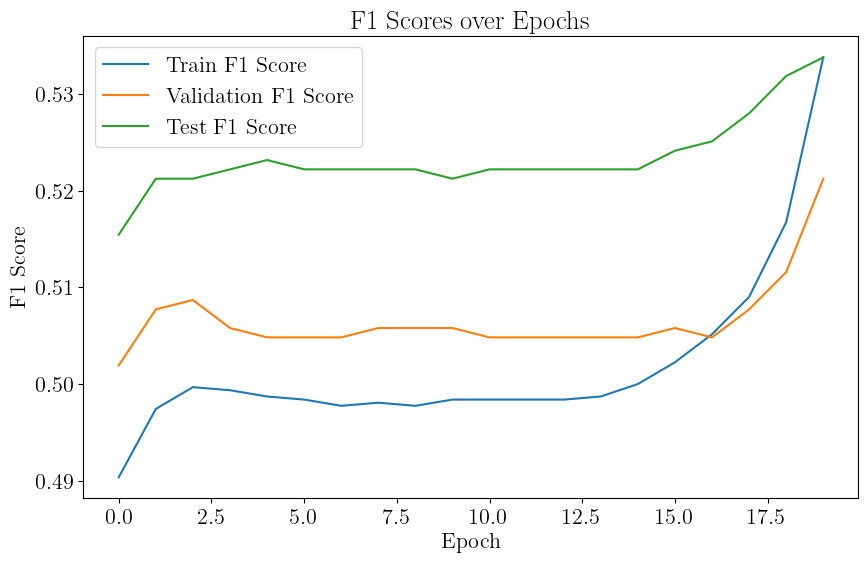

In [31]:
# Plot the F1 scores of last run
plt.figure(figsize=(10, 6))
plt.plot(train_f1_scores, label='Train F1 Score')
plt.plot(val_f1_scores, label='Validation F1 Score')
plt.plot(test_f1_scores, label='Test F1 Score')
# plt.plot(loss_scores, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Scores over Epochs')
plt.legend()
plt.show()

In [32]:
for batch in cluster_loader:
    print(batch.num_nodes)
    #print(batch.edge_index.shape)

5180
